In [1]:
import pandas as pd
import matplotlib.pyplot as plt

def count_values_in_column(csv_file, column_name, values_dict, chunksize=100000):
    
    counts = {id_value: 0 for id_value in values_dict.keys()}
    total_count = 0

    for chunk in pd.read_csv(csv_file, chunksize=chunksize):
        if column_name not in chunk.columns:
            print(f"Column '{column_name}' not found in file")
            return

        
        total_count += chunk[column_name].notna().sum()

        for id_value in values_dict.keys():
            counts[id_value] += (chunk[column_name].astype(str) == str(id_value)).sum()

    results = [(id_value, values_dict[id_value], counts[id_value], total_count) 
               for id_value in values_dict.keys()]

    for id_value, display_name, count, total in results:
        print(f"{id_value} ({display_name}): {count} / {total}")

    return results


In [2]:
# ID and their display names
values_dict = {
    "228640": "EtCO2"
}

csv_file = "/hpc/home/yy450/link_kamaleswaranlab/mimic_iv/builtdata/csv_exports/icu_chartevents.csv"
column_name = "itemid"


results = count_values_in_column(csv_file, column_name, values_dict, chunksize=500000)


228640 (EtCO2): 159348 / 432997491


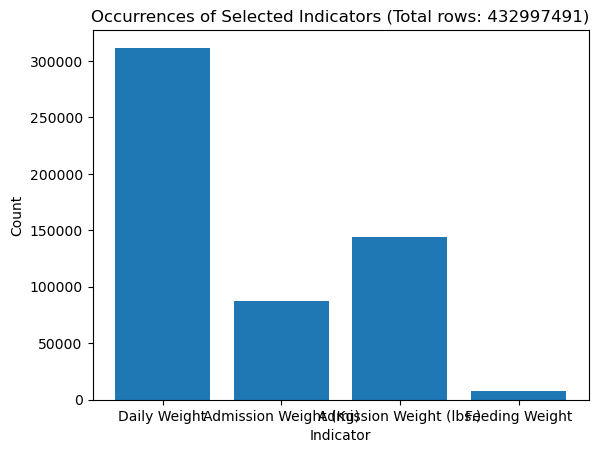

In [7]:
labels = [name for _, name, _, _ in results]  
counts = [count for _, _, count, _ in results]
total = results[0][3] 

plt.bar(labels, counts)
plt.xlabel("Indicator")
plt.ylabel("Count")
plt.title(f"Occurrences of Selected Indicators (Total rows: {total})")
plt.show()

This is for check if itemid 226707 (inch) and 226730 (cm) are the same data for a single record, which means that they are just in different units.

In [4]:
import pandas as pd

def compare_height_units(csv_file, chunksize=500000, tol=1.0):
    """
    比较 itemid 226707 (inch) 和 226730 (cm) 是否基本等价.
    tol: 容差（默认 1 英寸）
    """
    matches = 0
    total_pairs = 0

    for chunk in pd.read_csv(csv_file, chunksize=chunksize):
        # 只保留感兴趣的 itemid
        sub = chunk[chunk["itemid"].isin([226707, 226730])]

        if sub.empty:
            continue

        # pivot: 以 subject_id, hadm_id, charttime 为键，把 itemid 作为列
        # 假设有列 subject_id, hadm_id, charttime, valuenum
        pivoted = sub.pivot_table(
            index=["subject_id", "hadm_id", "charttime"],
            columns="itemid",
            values="valuenum",
            aggfunc="first"   # 如果重复，就取第一个
        )

        # 过滤掉缺失
        if 226707 in pivoted.columns and 226730 in pivoted.columns:
            # 转换 cm -> inch
            cm_in_inch = pivoted[226730] / 2.54
            inch = pivoted[226707]

            # 比较差异
            diff = (cm_in_inch - inch).abs()
            matches += (diff < tol).sum()
            total_pairs += len(diff)

    print(f"共找到 {total_pairs} 对记录，其中 {matches} 对在容差 {tol} 英寸内匹配")

    if total_pairs > 0:
        print(f"匹配比例: {matches / total_pairs:.2%}")
    else:
        print("没有找到同时有 cm 和 inch 的记录")

# 用法
compare_height_units(csv_file, chunksize=500000, tol=1.0)


共找到 43617 对记录，其中 43615 对在容差 1.0 英寸内匹配
匹配比例: 100.00%
